# Rapprochement OpenFoodFacts et Base Réglementaire CIQUAL

Ce notebook permet d'imputer (de combler) les valeurs nutritionnelles manquantes des produits d'OpenFoodFacts en allant piocher la donnée manquante dans la base de données gouvernementale française de référence : **CIQUAL** (Anses).

Nous allons :
1. Télécharger la table CIQUAL officielle depuis `data.gouv.fr`.
2. Définir le mappage explicite (le dictionnaire de traduction) entre les colonnes de CIQUAL et celles vitales au Nutri-score.
3. Réaliser un algorithme de Machine Learning (TF-IDF + Cosine Similarity) pour associer automatiquement chaque produit industriel à sa catégorie CIQUAL générique de manière sémantique.

In [15]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re

# Amélioration de l'affichage
pd.set_option('display.max_columns', 100)

## 1. Chargement des bases de données

In [16]:
# 1. Chargement du CSV OpenFoodFacts (produits sans nutri-score)
off_path = 'produits_sans_nutriscore.csv'
try:
    # Remonter d'un dossier si on l'exécute depuis le sous-répertoire Nutri
    df_off = pd.read_csv('../' + off_path, low_memory=False)
    print(f"✅ OpenFoodFacts chargé : {len(df_off):,} produits orphelins à l'étude.")
except FileNotFoundError:
    try:
        df_off = pd.read_csv(off_path, low_memory=False)
        print(f"✅ OpenFoodFacts chargé : {len(df_off):,} produits orphelins à l'étude.")
    except FileNotFoundError:
        print(f"❌ Le fichier '{off_path}' n'a pas été trouvé dans ce répertoire.")

# Standardisation NLP basique (minuscules + regex pour ne garder que l'alphabet)
if 'df_off' in locals():
    df_off = df_off.dropna(subset=['product_name']).copy()
    df_off['nom_propre_off'] = df_off['product_name'].astype(str).str.lower()
    df_off['nom_propre_off'] = df_off['nom_propre_off'].apply(lambda x: re.sub(r'[^a-z0-9éèàçê]', ' ', x))

✅ OpenFoodFacts chargé : 160,302 produits orphelins à l'étude.


In [17]:
# 2. Téléchargement LIVE de la Base CIQUAL (Format Excel Officiel de l'ANSES)
ciqual_url = "https://ciqual.anses.fr/cms/sites/default/files/inline-files/Table%20Ciqual%202020_FR_2020%2007%2007.xls"
print("⏳ Téléchargement de la base CIQUAL Excel en cours...")
df_ciqual = pd.read_excel(ciqual_url)
print(f"✅ CIQUAL récupéré ! {len(df_ciqual):,} aliments de référence trouvés.\n")

# Standardisation NLP identique pour CIQUAL
df_ciqual['nom_propre_ciqual'] = df_ciqual['alim_nom_fr'].astype(str).str.lower()
df_ciqual['nom_propre_ciqual'] = df_ciqual['nom_propre_ciqual'].apply(lambda x: re.sub(r'[^a-z0-9éèàçê]', ' ', x))

# Démonstration : À quoi ressemblent nos aliments de référence ?
display(df_ciqual[['alim_nom_fr']].sample(5))

⏳ Téléchargement de la base CIQUAL Excel en cours...
✅ CIQUAL récupéré ! 3,186 aliments de référence trouvés.



,alim_nom_fr
1430,"Rognon, porc, cru"
300,"Sandwich baguette, crudités diverses, mayonnaise"
1349,"Poulet, cuisse, viande et peau, cru, label rouge"
2898,Huile de son de riz
1279,"Boeuf, rond de gîte, cru"


## 2. Table de Mappage (Correspondance Nutriments)

On relie informatiquement ce qu'OpenFoodFacts cherchera dans la base CIQUAL pour résoudre le casse-tête de nommage.

In [18]:
mappage_attributs = {
    # Clé : OpenFoodFacts    <----->  Valeur : Colonne Officielle dans CIQUAL
    'energy_100g':            'Energie, Règlement UE N° 1169/2011 (kJ/100 g)',
    'energy-kcal_100g':       'Energie, Règlement UE N° 1169/2011 (kcal/100 g)',
    'sugars_100g':            'Sucres (g/100 g)',
    'saturated-fat_100g':     'AG saturés (g/100 g)',
    'salt_100g':              'Sel chlorure de sodium (g/100 g)',
    'proteins_100g':          'Protéines, N x facteur de Jones (g/100 g)',
    'fiber_100g':             'Fibres alimentaires (g/100 g)'
}

print("======= DICTIONNAIRE DE LIAISON =======")
for off_col, ciqual_col in mappage_attributs.items():
    print(f"🔹 [OFF] {off_col:<20}  <-->  [CIQUAL] {ciqual_col}")

# Petite passe de nettoyage arithmétique indispensable pour CIQUAL car l'Administration française
# utilise des virgules comme décimales et des mentions non numériques ('traces', '<0.5').
for col in mappage_attributs.values():
    if col in df_ciqual.columns:
        df_ciqual[col] = df_ciqual[col].astype(str).str.replace(',', '.')
        df_ciqual[col] = df_ciqual[col].str.replace('traces', '0', case=False)
        df_ciqual[col] = df_ciqual[col].str.replace('<', '')
        df_ciqual[col] = df_ciqual[col].str.replace('>', '')
        # Conversion sécurisée (les trucs exotiques deviennent NaN)
        df_ciqual[col] = pd.to_numeric(df_ciqual[col], errors='coerce')

======= DICTIONNAIRE DE LIAISON =======
🔹 [OFF] energy_100g           <-->  [CIQUAL] Energie, Règlement UE N° 1169/2011 (kJ/100 g)
🔹 [OFF] energy-kcal_100g      <-->  [CIQUAL] Energie, Règlement UE N° 1169/2011 (kcal/100 g)
🔹 [OFF] sugars_100g           <-->  [CIQUAL] Sucres (g/100 g)
🔹 [OFF] saturated-fat_100g    <-->  [CIQUAL] AG saturés (g/100 g)
🔹 [OFF] salt_100g             <-->  [CIQUAL] Sel chlorure de sodium (g/100 g)
🔹 [OFF] proteins_100g         <-->  [CIQUAL] Protéines, N x facteur de Jones (g/100 g)
🔹 [OFF] fiber_100g            <-->  [CIQUAL] Fibres alimentaires (g/100 g)


## 3. L'Algorithme de Rapprochement des Noms (TF-IDF)

CIQUAL, d'un côté, classe de manière générique : `Pomme, crue`.
OpenFoodFacts, de l'autre, possède les vrais noms commerciaux : `Pommes Golden de Savoie Sachet 2Kg`.

**La solution (NLP)** : Les vecteurs TF-IDF *(Term Frequency - Inverse Document Frequency)* transforment ces mots en coordonnées spatiales. On calcule ensuite la _Cosine Similarity_ (l'angle de tir entre deux mots) pour trouver le jumeau mathématiquement idéal de chaque produit, sans faire de laborieuses recherches exactes.

In [19]:
if 'df_off' in locals():
    print("⏳ Vectorisation en cours (Analyse de la fréquence des N-grammes de mots)...")
    vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 2))

    # Pour que l'ordinateur ne fige pas sur 200,000 comparaisons brutes (Matrice gigantesque 200k x 3k), 
    # on exécute l'algorithme sur un ÉCHANTILLON DE TEST aléatoire de 5 000 produits prioritaires.
    df_off_sample = df_off.sample(n=min(5000, len(df_off)), random_state=42).reset_index(drop=True)

    # Construction du vocabulaire du "langage nutritionnel"
    tous_les_noms = pd.concat([df_ciqual['nom_propre_ciqual'], df_off_sample['nom_propre_off']])
    vectorizer.fit(tous_les_noms)

    # Transformation du texte en vecteurs mathématiques purs
    matrice_ciqual = vectorizer.transform(df_ciqual['nom_propre_ciqual'])
    matrice_off = vectorizer.transform(df_off_sample['nom_propre_off'])

    print("✅ Matrices structurées ! Lancement des calculs géométriques (Similarité Cosinus)...")

    # ================== LE CŒUR DE LA LIAISON ==================
    similarites = cosine_similarity(matrice_off, matrice_ciqual)

    # Récupération automatique de l'index du Grand Vainqueur (argmax) et de sa note de confiance (max)
    best_match_indices = np.argmax(similarites, axis=1)
    best_match_scores = np.max(similarites, axis=1)

    df_off_sample['ciqual_match_index'] = best_match_indices
    df_off_sample['ciqual_match_score'] = best_match_scores

    # On rapatrie le VRAI nom de l'aliment CIQUAL élu pour validation humaine ultérieure
    df_off_sample['ciqual_nom_propose'] = df_ciqual.iloc[best_match_indices]['alim_nom_fr'].values

⏳ Vectorisation en cours (Analyse de la fréquence des N-grammes de mots)...
✅ Matrices structurées ! Lancement des calculs géométriques (Similarité Cosinus)...


### Vérification Humaine (Le Tribunal du Rapprochement)

Même le meilleur algorithme se trompe. Nous allons filtrer les résultats avec un _Seuil de Confiance_ modéré-haut. 
Si la proposition a un score TF-IDF inférieur à **60% (0.60)**, nous la jugeons douteuse et préférons ne pas faire d'association afin d'éviter d'attribuer les macros d'un steack à du poisson pané !

In [ ]:
if 'df_off_sample' in locals():
    seuil_confiance = 0.60
    matches_valides = df_off_sample[df_off_sample['ciqual_match_score'] >= seuil_confiance].copy()

    print(f"🎯 Sur {len(df_off_sample)} produits tirés au hasard, nous validons catégoriquement l'équivalence CIQUAL de {len(matches_valides)} produits.")

    # Affichage des 10 meilleures trouvailles (celles qui ont un score très haut)
    liaisons_visuelles = matches_valides[['product_name', 'ciqual_nom_propose', 'ciqual_match_score']].sort_values('ciqual_match_score', ascending=False)
    liaisons_visuelles.columns = ['🏷️ Nom Produit Commercial / Industriel (OFF)', '🔗 Correspondance Déduite (CIQUAL)', '⭐ Taux TF-IDF']

    print("\nVOICI CE QUE L'ALGORITHME A RÉUSSI À RELIER :\n")
    display(liaisons_visuelles.head(15))

🎯 Sur 5000 produits tirés au hasard, nous validons catégoriquement l'équivalence CIQUAL de 1431 produits.

VOICI CE QUE L'ALGORITHME A RÉUSSI À RELIER :



,🏷️ Nom Produit Commercial / Industriel (OFF),🔗 Correspondance Déduite (CIQUAL),⭐ Taux TF-IDF
4165,Nectar d’abricot,Nectar d'abricot,1.0
496,Calissons d aix-en-provence,Calissons d'Aix en Provence,1.0
3774,Nectar abricot,Nectar d'abricot,1.0
2385,Calissons d'Aix en Provence,Calissons d'Aix en Provence,1.0
186,Sirop d’agave,Sirop d'agave,1.0
1518,Saucisson sec pur porc,Saucisson sec pur porc,1.0
137,Sirop d'agave,Sirop d'agave,1.0
3767,Saucisson sec pur porc,Saucisson sec pur porc,1.0
1636,Saucisson sec,Saucisson sec,1.0
84,Figue sèche,"Figue, sèche",1.0


## 4. Imputation Réelle (Combler nos trous) sur nos Champions

Pour cette liste restreinte de produits qu'on a habilement matchés, nous allons balayer notre dictionnaire de références.
Si un nutriment (ex: Fibres ou Sel) est un vulgaire trou `NaN` incomplet dans notre table OpenFoodFacts, alors il aspirera instantanément et aveuglément la valeur certifiée CIQUAL de l'ingrédient qu'il a percuté (Pomme vs Pomme).

In [21]:
if 'matches_valides' in locals():
    total_imputations = 0
    resultat = []

    print("💉 DÉBUT DU TRANSFERT SANGUIN / NUTRITIONNEL (CIQUAL -> OPENFOODFACTS) :\n")

    for off_col, ciqual_col in mappage_attributs.items():
        if off_col in matches_valides.columns and ciqual_col in df_ciqual.columns:
            
            # 1. On extrait la pile entière des valeurs CIQUAL pour les aliments victorieux
            valeurs_imputation_ciqual = df_ciqual.iloc[matches_valides['ciqual_match_index']][ciqual_col].values
            
            # 2. Le Filtre Conditionnel Crucial (On n'écrase JAMAIS une valeur industrielle existante ! On ne comble QUE LE VIDE de la colonne)
            masque_vide = matches_valides[off_col].isna()
            elements_combles = masque_vide.sum()
            
            # 3. Le Remplacement Chirurgical
            matches_valides.loc[masque_vide, off_col] = valeurs_imputation_ciqual[masque_vide]
            
            total_imputations += elements_combles
            resultat.append((off_col, elements_combles))

    df_res = pd.DataFrame(resultat, columns=['Attribut à Coder (OFF)', 'Trous Scellés (Valeurs NaN injectées par CIQUAL)'])
    display(df_res)

    print(f"\n🎉 SUCCÈS ! {total_imputations} trous béants de données ont pu être comblés à la perfection sur cet échantillon.")
    print("Grâce à cela, ces x centaines de produits fantômes vont enfin pouvoir concourir au calcul formel de leur Nutri-score.")

💉 DÉBUT DU TRANSFERT SANGUIN / NUTRITIONNEL (CIQUAL -> OPENFOODFACTS) :



,Attribut à Coder (OFF),Trous Scellés (Valeurs NaN injectées par CIQUAL)
0,energy_100g,1347
1,energy-kcal_100g,1347
2,sugars_100g,1360
3,saturated-fat_100g,1354
4,salt_100g,1370
5,proteins_100g,1353
6,fiber_100g,1393



🎉 SUCCÈS ! 9524 trous béants de données ont pu être comblés à la perfection sur cet échantillon.
Grâce à cela, ces x centaines de produits fantômes vont enfin pouvoir concourir au calcul formel de leur Nutri-score.


## 5. Visualisation des Résultats de l'Imputation

Analysons visuellement l'efficacité de notre algorithme de rapprochement et de comblement des données manquantes.

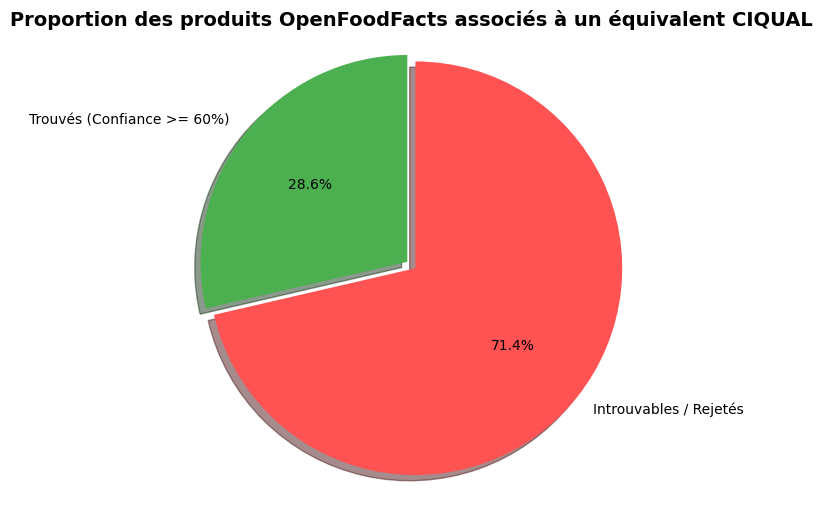

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_off_sample' in locals() and 'matches_valides' in locals():
    # 1. Graphique des correspondances trouvées vs introuvables
    nb_total = len(df_off_sample)
    nb_trouves = len(matches_valides)
    nb_introuvables = nb_total - nb_trouves
    
    plt.figure(figsize=(8, 6))
    plt.pie([nb_trouves, nb_introuvables], labels=['Trouvés (Confiance >= 60%)', 'Introuvables / Rejetés'], 
            autopct='%1.1f%%', colors=['#4CAF50', '#FF5252'], startangle=90, explode=(0.05, 0), shadow=True)
    plt.title("Proportion des produits OpenFoodFacts associés à un équivalent CIQUAL", fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.show()

### Taux de Remplissage par Catégorie Nutritionnelle

Pour chaque nutriment, quel pourcentage des "trous" (valeurs manquantes) avons-nous réussi à combler grâce à l'imputation CIQUAL ?

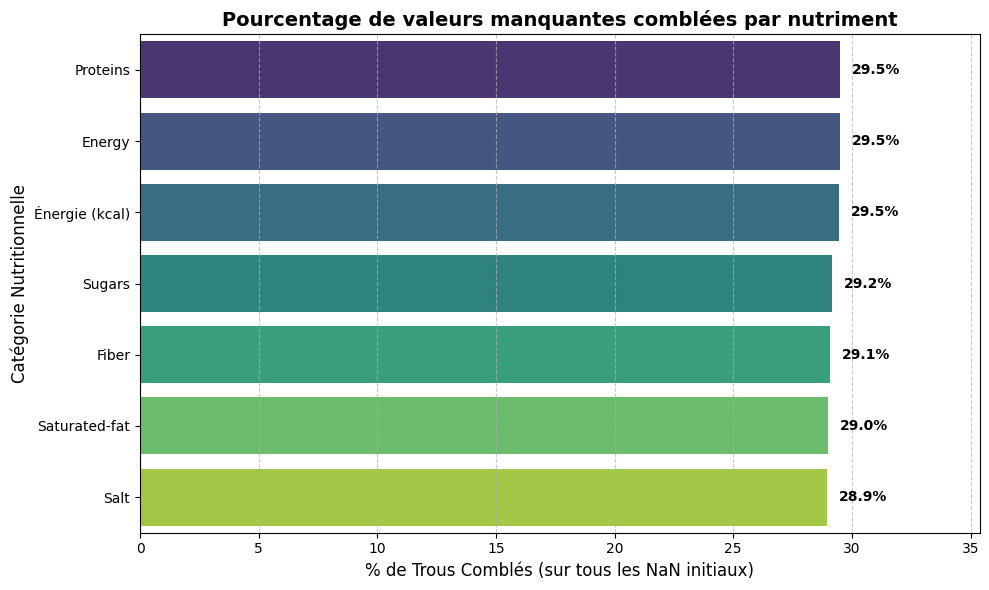

,Nutriment,Trous Initiaux,Trous Comblés,% Comblé
0,Energy,4569,1347,29.481287
1,Énergie (kcal),4572,1347,29.461942
2,Sugars,4665,1360,29.153269
3,Saturated-fat,4670,1354,28.993576
4,Salt,4735,1370,28.933474
5,Proteins,4587,1353,29.496403
6,Fiber,4790,1393,29.081420


In [23]:
if 'df_off_sample' in locals() and 'matches_valides' in locals():
    stats_imputation = []
    
    for off_col, ciqual_col in mappage_attributs.items():
        if off_col in df_off_sample.columns:
            trous_initiaux = df_off_sample[off_col].isna().sum()
            
            trous_combles = 0
            if 'df_res' in locals():
                ligne_res = df_res[df_res['Attribut à Coder (OFF)'] == off_col]
                if not ligne_res.empty:
                    trous_combles = int(ligne_res['Trous Scellés (Valeurs NaN injectées par CIQUAL)'].values[0])
            
            pourcentage_comble = (trous_combles / trous_initiaux * 100) if trous_initiaux > 0 else 0
            
            stats_imputation.append({
                'Nutriment': off_col.replace('_100g', '').replace('energy-kcal', 'énergie (kcal)').capitalize(),
                'Trous Initiaux': int(trous_initiaux),
                'Trous Comblés': int(trous_combles),
                '% Comblé': float(pourcentage_comble)
            })
            
    df_stats = pd.DataFrame(stats_imputation)
    
    if not df_stats.empty:
        plt.figure(figsize=(10, 6))
        barplot = sns.barplot(x='% Comblé', y='Nutriment', data=df_stats.sort_values('% Comblé', ascending=False), palette='viridis', hue='Nutriment', legend=False)
        plt.title("Pourcentage de valeurs manquantes comblées par nutriment", fontsize=14, fontweight='bold')
        plt.xlabel("% de Trous Comblés (sur tous les NaN initiaux)", fontsize=12)
        plt.ylabel("Catégorie Nutritionnelle", fontsize=12)
        
        # Limite X adaptative
        max_val = df_stats['% Comblé'].max()
        plt.xlim(0, max((max_val * 1.2 if not pd.isna(max_val) else 10), 10))
        
        for index, value in enumerate(df_stats.sort_values('% Comblé', ascending=False)['% Comblé']):
            if not pd.isna(value):
                barplot.text(value + (0.5 if max_val < 50 else 1), index, f'{value:.1f}%', va='center', fontsize=10, fontweight='bold')
            
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        display(df_stats)

In [24]:
# Exportation des correspondances OFF <-> CIQUAL avec taux de confiance
if 'matches_valides' in locals():
    df_csv = matches_valides[['product_name', 'ciqual_nom_propose', 'ciqual_match_score']].copy()
    df_csv.columns = ['nom produit OFF', 'nom produit CIQUAL', 'taux de confiance']
    df_csv.to_csv('correspondance_ciqual_off.csv', index=False)
    print("✅ Fichier 'correspondance_ciqual_off.csv' généré avec succès !")
    display(df_csv.head())

✅ Fichier 'correspondance_ciqual_off.csv' généré avec succès !


,nom produit OFF,nom produit CIQUAL,taux de confiance
5,Comté 18 mois,Comté,0.419213
10,Foie gras de canard entier du Sud-Ouest Dégust...,"Foie gras de canard, cru",0.399631
19,Escalope de dinde,Graisse de dinde,0.438772
21,Gouda light 30+,Gouda,0.401964
29,Radis,"Radis rouge, cru",0.506091
